In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.4 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Knee_YOLO_Project"

DATASETS_DIR = os.path.join(PROJECT_DIR, "Datasets")

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")

PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "Predictions")

GRAPHS_DIR = os.path.join(PROJECT_DIR, "Graphs")

In [ ]:
DATASET_100_DIR = os.path.join(
    DATASETS_DIR,
    "dataset_100"
)

DATASET_100_YAML = os.path.join(
    DATASET_100_DIR,
    "dataset_100.yaml"
)

print(DATASET_100_YAML)

/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/dataset_100.yaml


In [ ]:
import os

RAW_IMAGES = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/images"
RAW_LABELS = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/labels"

print("Images :", len(os.listdir(RAW_IMAGES)))
print("Labels :", len(os.listdir(RAW_LABELS)))

Images : 101
Labels : 101


In [ ]:
import os

DATASET_100_DIR = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100"

folders = [

    "train/images",
    "train/labels",

    "valid/images",
    "valid/labels",

    "test/images",
    "test/labels"

]

for folder in folders:

    os.makedirs(
        os.path.join(DATASET_100_DIR, folder),
        exist_ok=True
    )

print("Folders created successfully.")

Folders created successfully.


In [ ]:
import os
import shutil
import random

random.seed(42)

RAW_IMAGES = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/images"
RAW_LABELS = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/labels"

images = sorted(os.listdir(RAW_IMAGES))

random.shuffle(images)

train = images[:80]
valid = images[80:90]
test = images[90:100]

splits = {

    "train": train,
    "valid": valid,
    "test": test

}

for split, files in splits.items():

    for image in files:

        shutil.copy(
            os.path.join(RAW_IMAGES, image),
            os.path.join(DATASET_100_DIR, split, "images", image)
        )

        label = os.path.splitext(image)[0] + ".txt"

        shutil.copy(
            os.path.join(RAW_LABELS, label),
            os.path.join(DATASET_100_DIR, split, "labels", label)
        )

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [ ]:
for folder in [

    "train/images",
    "train/labels",

    "valid/images",
    "valid/labels",

    "test/images",
    "test/labels"

]:

    path = os.path.join(DATASET_100_DIR, folder)

    print(folder, ":", len(os.listdir(path)))

train/images : 80
train/labels : 80
valid/images : 10
valid/labels : 10
test/images : 10
test/labels : 10


In [ ]:
import os

DATASET_100_YAML = os.path.join(
    DATASET_100_DIR,
    "dataset_100.yaml"
)

yaml_content = f"""
path: {DATASET_100_DIR}

train: train/images
val: valid/images
test: test/images

names:
  0: knee
"""

with open(DATASET_100_YAML, "w") as f:
    f.write(yaml_content)

print("YAML file created successfully.")
print(DATASET_100_YAML)

YAML file created successfully.
/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/dataset_100.yaml


In [ ]:
with open(DATASET_100_YAML, "r") as f:
    print(f.read())


path: /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100

train: train/images
val: valid/images
test: test/images

names:
  0: knee



In [ ]:
from ultralytics import YOLO
import os

best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_70",
        "weights",
        "best.pt"
    )
)

print("70-image model loaded successfully.")

70-image model loaded successfully.


In [ ]:
results = best_model.train(
    data=DATASET_100_YAML,
    epochs=100,
    imgsz=640,
    batch=16,
    project=RESULTS_DIR,
    name="YOLO11n_100",
    exist_ok=True
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/dataset_100.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Knee_YOLO_Project/Results/YOLO11n_70/weight

In [ ]:
best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_100",
        "weights",
        "best.pt"
    )
)

print("100-image model loaded successfully.")

100-image model loaded successfully.


In [ ]:
from ultralytics import YOLO
import os
import pandas as pd

# Load the best 100-image model
best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_100",
        "weights",
        "best.pt"
    )
)

# Evaluate the model
metrics = best_model.val(
    data=DATASET_100_YAML
)

# Store the evaluation metrics
results_100 = {
    "Dataset Size": 100,
    "Precision": round(metrics.box.mp, 3),
    "Recall": round(metrics.box.mr, 3),
    "mAP50": round(metrics.box.map50, 3),
    "mAP50:95": round(metrics.box.map, 3)
}

# Display the results
results_100_df = pd.DataFrame([results_100])

print("\nYOLO11n - 100 Image Experiment Results\n")
display(results_100_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.8±2.0 ms, read: 137.3±73.9 MB/s, size: 7428.4 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1s/it 2.1s
                   all         10         10      0.994          1      0.995      0.793
Speed: 0.3ms preprocess, 3.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val-2

YOLO11n - 100 Image Experiment Results



,Dataset Size,Precision,Recall,mAP50,mAP50:95
0,100,0.994,1.0,0.995,0.793


In [ ]:
import os

PREDICTIONS_100_DIR = os.path.join(
    PREDICTIONS_DIR,
    "YOLO11n_100"
)

os.makedirs(PREDICTIONS_100_DIR, exist_ok=True)

print(PREDICTIONS_100_DIR)

/content/drive/MyDrive/Knee_YOLO_Project/Predictions/YOLO11n_100


In [ ]:
from ultralytics import YOLO
import os

test_images = os.path.join(
    DATASET_100_DIR,
    "test",
    "images"
)

best_model.predict(
    source=test_images,
    save=True,
    project=PREDICTIONS_DIR,
    name="YOLO11n_100",
    exist_ok=True,
    conf=0.25
)


image 1/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/1013K1_L.png: 640x384 1 knee, 52.1ms
image 2/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/1109K1_L.png: 640x384 1 knee, 8.4ms
image 3/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/1123K1_L.png: 640x384 1 knee, 8.6ms
image 4/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/11323K1_R.png: 640x384 1 knee, 11.7ms
image 5/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/11411K1_L.png: 640x384 1 knee, 8.8ms
image 6/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/11429K1_R.png: 640x384 1 knee, 15.3ms
image 7/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/11445K1_R.png: 640x384 1 knee, 11.2ms
image 8/10 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_100/test/images/47127K1_R.png: 640x384 1 knee, 10.9ms
image 9/10 /content/d

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'knee'}
 obb: None
 orig_img: array([[[177, 177, 177],
         [182, 182, 182],
         [177, 177, 177],
         ...,
         [125, 125, 125],
         [166, 166, 166],
         [218, 218, 218]],
 
        [[180, 180, 180],
         [180, 180, 180],
         [178, 178, 178],
         ...,
         [137, 137, 137],
         [124, 124, 124],
         [128, 128, 128]],
 
        [[173, 173, 173],
         [172, 172, 172],
         [173, 173, 173],
         ...,
         [172, 172, 172],
         [158, 158, 158],
         [140, 140, 140]],
 
        ...,
 
        [[101, 101, 101],
         [102, 102, 102],
         [104, 104, 104],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[105, 105, 105],
         [101, 101, 101],
         [100, 100, 100],
         ...,
       

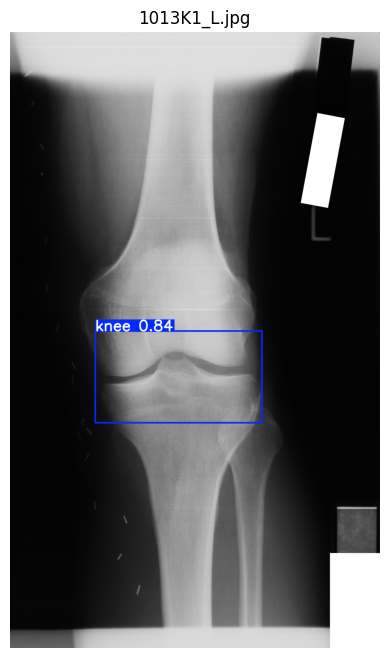

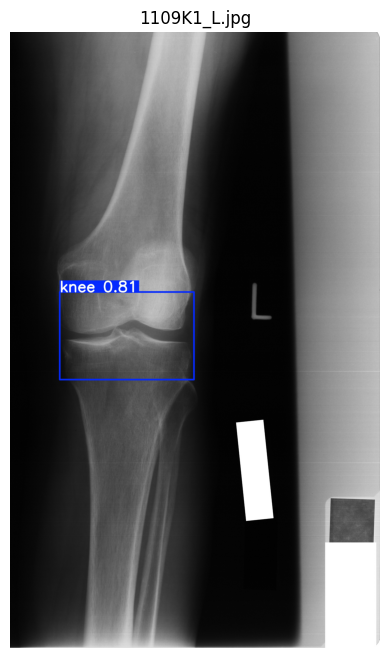

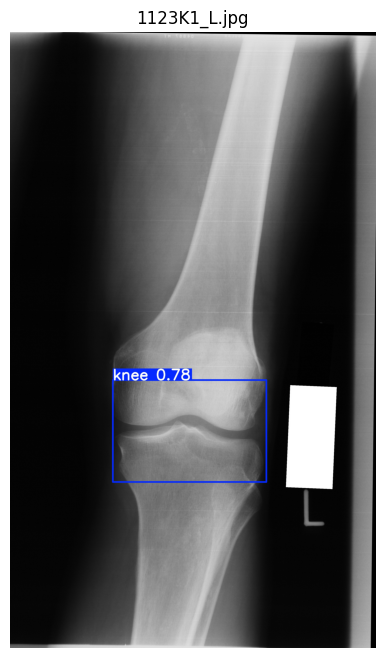

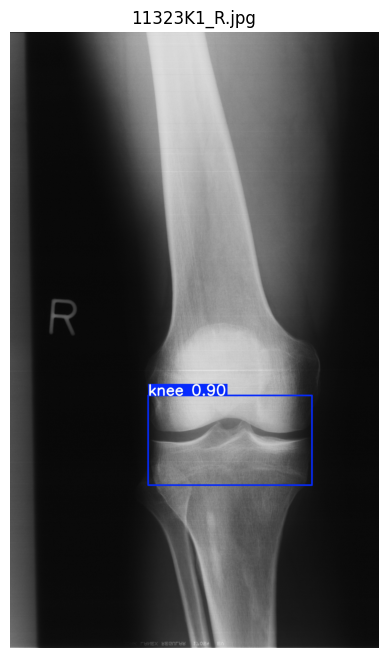

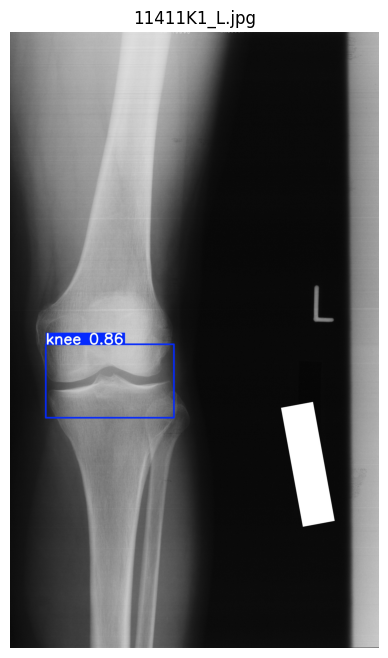

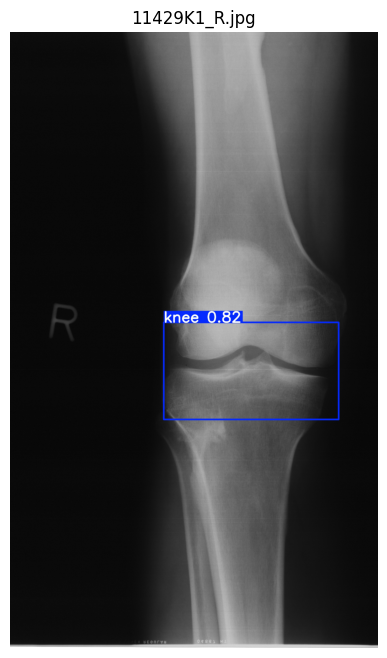

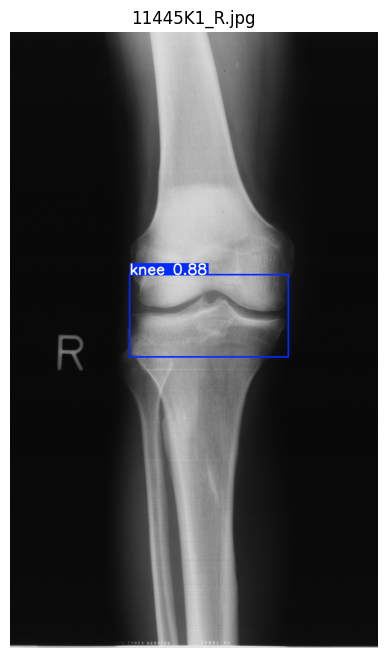

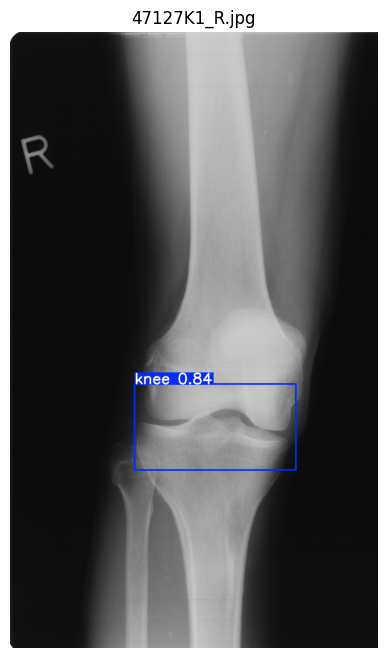

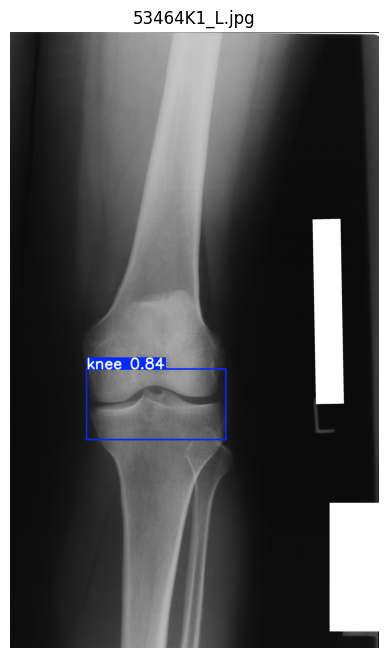

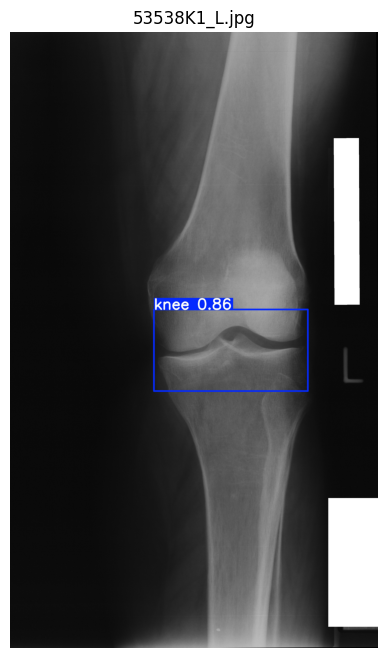

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

prediction_folder = os.path.join(
    PREDICTIONS_DIR,
    "YOLO11n_100"
)

images = sorted([
    img for img in os.listdir(prediction_folder)
    if img.lower().endswith((".png", ".jpg", ".jpeg"))
])

for image_name in images:

    img = Image.open(os.path.join(prediction_folder, image_name))

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd
import os

results_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "results_summary.csv")
)

display(results_df)

,Dataset Size,Training Images,Validation Images,Test Images,Precision,Recall,mAP@50,mAP@50:95
0,30,24,3,3,0.9860,1.0,0.995,0.775
1,50,40,5,5,0.9860,1.0,0.995,0.775
2,70,56,7,7,0.9927,1.0,0.995,0.763


In [ ]:
# Fill the missing values in the new columns
results_df["mAP50"] = results_df["mAP50"].fillna(results_df["mAP@50"])
results_df["mAP50:95"] = results_df["mAP50:95"].fillna(results_df["mAP@50:95"])

# Fill dataset split information
results_df.loc[results_df["Dataset Size"] == 100, "Training Images"] = 80
results_df.loc[results_df["Dataset Size"] == 100, "Validation Images"] = 10
results_df.loc[results_df["Dataset Size"] == 100, "Test Images"] = 10

# Remove duplicate columns
results_df = results_df.drop(columns=["mAP@50", "mAP@50:95"])

display(results_df)

,Dataset Size,Training Images,Validation Images,Test Images,Precision,Recall,mAP50,mAP50:95
0,30,24.0,3.0,3.0,0.9860,1.0,0.995,0.775
1,50,40.0,5.0,5.0,0.9860,1.0,0.995,0.775
2,70,56.0,7.0,7.0,0.9927,1.0,0.995,0.763
3,100,80.0,10.0,10.0,0.9940,1.0,0.995,0.793


In [ ]:
results_df.to_csv(
    os.path.join(RESULTS_DIR, "results_summary.csv"),
    index=False
)

In [ ]:
import os

GRAPHS_DIR = os.path.join(PROJECT_DIR, "Graphs")

os.makedirs(GRAPHS_DIR, exist_ok=True)

print("Graphs folder:", GRAPHS_DIR)

Graphs folder: /content/drive/MyDrive/Knee_YOLO_Project/Graphs


In [ ]:
print(os.path.exists(GRAPHS_DIR))

True


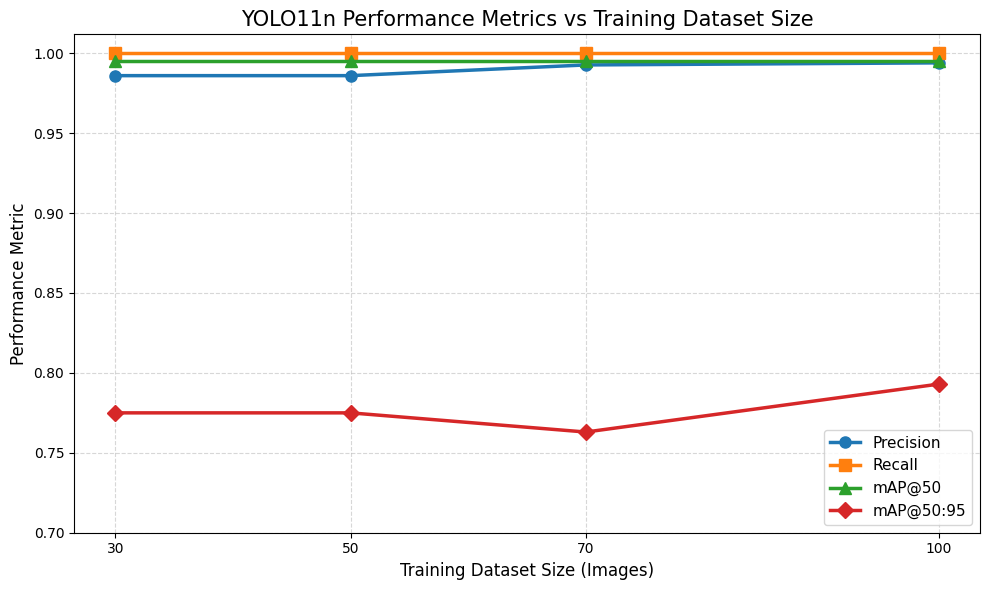

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    results_df["Dataset Size"],
    results_df["Precision"],
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Precision'
)

plt.plot(
    results_df["Dataset Size"],
    results_df["Recall"],
    marker='s',
    linewidth=2.5,
    markersize=8,
    label='Recall'
)

plt.plot(
    results_df["Dataset Size"],
    results_df["mAP50"],
    marker='^',
    linewidth=2.5,
    markersize=8,
    label='mAP@50'
)

plt.plot(
    results_df["Dataset Size"],
    results_df["mAP50:95"],
    marker='D',
    linewidth=2.5,
    markersize=8,
    label='mAP@50:95'
)

plt.title("YOLO11n Performance Metrics vs Training Dataset Size", fontsize=15)
plt.xlabel("Training Dataset Size (Images)", fontsize=12)
plt.ylabel("Performance Metric", fontsize=12)

plt.xticks([30, 50, 70, 100])
plt.yticks([0.70,0.75,0.80,0.85,0.90,0.95,1.00])

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()

plt.savefig(
    os.path.join(GRAPHS_DIR, "YOLO11n_Performance_Curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# **Testing the Images on Unseen Data (40 Images)**

In [ ]:
import os

UNKNOWN_IMAGES_DIR = os.path.join(
    PROJECT_DIR,
    "Unknown_Images"
)

print(UNKNOWN_IMAGES_DIR)
print("Number of images:", len(os.listdir(UNKNOWN_IMAGES_DIR)))

/content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images
Number of images: 40


In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_100",
        "weights",
        "best.pt"
    )
)

print("YOLO11n 100-image model loaded successfully.")

YOLO11n 100-image model loaded successfully.


In [ ]:
results = best_model.predict(
    source=UNKNOWN_IMAGES_DIR,
    save=True,
    save_conf=True,
    conf=0.25,
    project=PREDICTIONS_DIR,
    name="Unknown_Images",
    exist_ok=True
)

print("Prediction completed successfully.")


image 1/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41432K1_L.png: 640x384 1 knee, 10.6ms
image 2/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41432K1_R.png: 640x384 1 knee, 9.4ms
image 3/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41435K1_L.png: 640x384 1 knee, 9.0ms
image 4/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41435K1_R.png: 640x384 1 knee, 11.7ms
image 5/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41440K1_L.png: 640x384 1 knee, 8.8ms
image 6/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41440K1_R.png: 640x384 1 knee, 9.1ms
image 7/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41448K1_L.png: 640x384 1 knee, 9.1ms
image 8/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41448K1_R.png: 640x384 1 knee, 15.5ms
image 9/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/41451K1_L.png: 640x384 1 knee, 8.7ms
image 10/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown

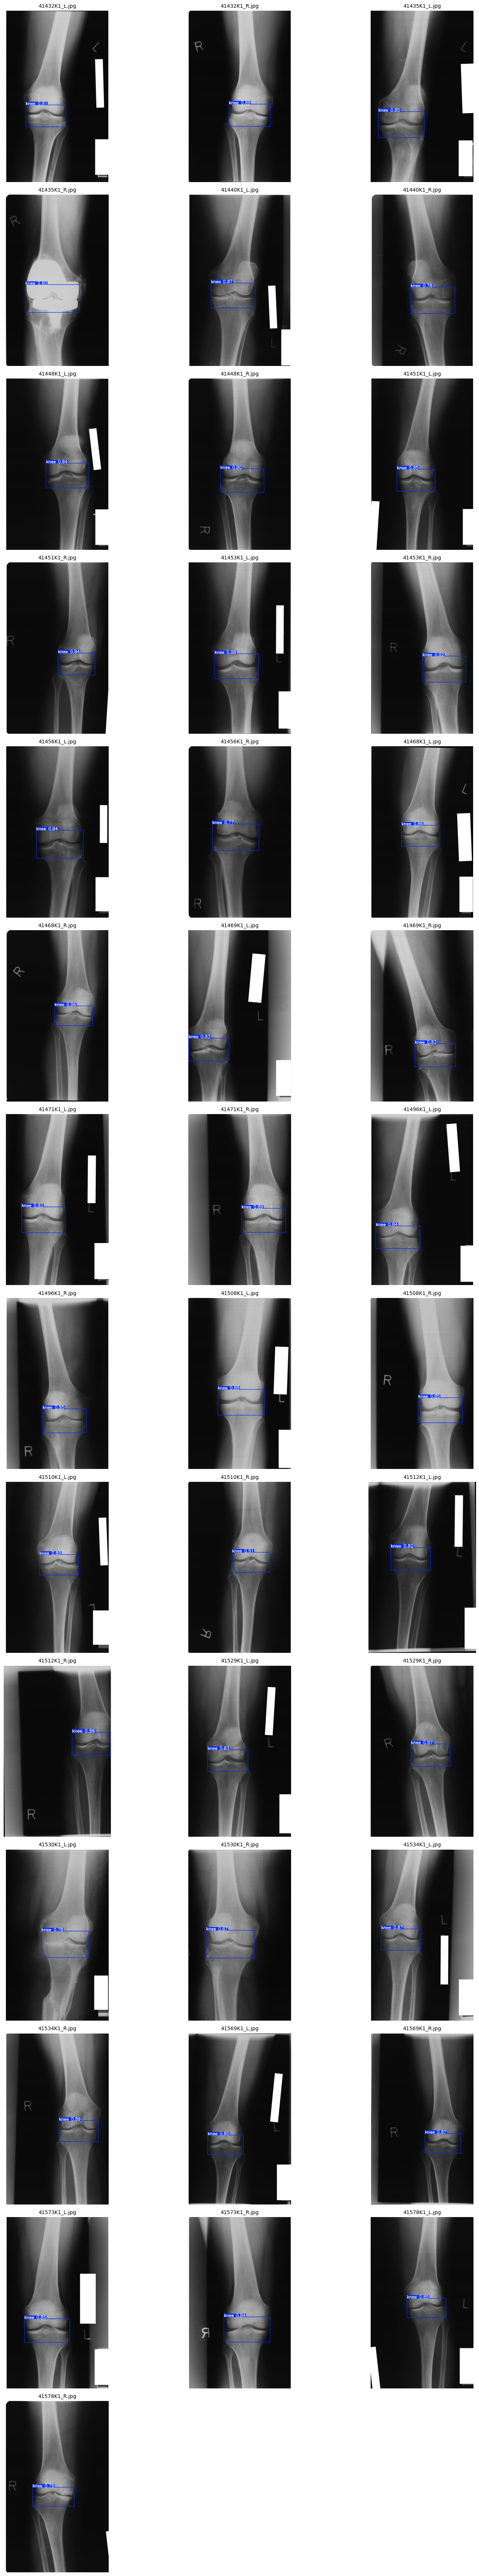

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

prediction_folder = os.path.join(
    PREDICTIONS_DIR,
    "Unknown_Images"
)

images = sorted([
    img for img in os.listdir(prediction_folder)
    if img.lower().endswith((".png", ".jpg", ".jpeg"))
])

cols = 3
rows = (len(images) + cols - 1) // cols

plt.figure(figsize=(15, rows * 5))

for i, image_name in enumerate(images):

    img = Image.open(os.path.join(prediction_folder, image_name))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(image_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        GRAPHS_DIR,
        "Unseen_Image_Predictions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
for i, result in enumerate(results):

    print(f"\nImage {i+1}: {os.path.basename(result.path)}")

    for j, box in enumerate(result.boxes):

        confidence = float(box.conf)
        cls = int(box.cls)
        xyxy = box.xyxy[0].tolist()

        print(f" Detection {j+1}")
        print(f"   Class      : {cls}")
        print(f"   Confidence : {confidence:.4f}")
        print(f"   Bounding Box: {[round(x,2) for x in xyxy]}")


Image 1: 41432K1_L.png
 Detection 1
   Class      : 0
   Confidence : 0.9093
   Bounding Box: [475.3, 2303.29, 1455.4, 2840.04]

Image 2: 41432K1_R.png
 Detection 1
   Class      : 0
   Confidence : 0.8859
   Bounding Box: [983.68, 2284.6, 1994.97, 2829.39]

Image 3: 41435K1_L.png
 Detection 1
   Class      : 0
   Confidence : 0.8543
   Bounding Box: [186.39, 2454.94, 1301.16, 3087.52]

Image 4: 41435K1_R.png
 Detection 1
   Class      : 0
   Confidence : 0.6003
   Bounding Box: [475.72, 2191.69, 1790.59, 2868.86]

Image 5: 41440K1_L.png
 Detection 1
   Class      : 0
   Confidence : 0.8656
   Bounding Box: [529.7, 2166.01, 1609.86, 2775.98]

Image 6: 41440K1_R.png
 Detection 1
   Class      : 0
   Confidence : 0.7803
   Bounding Box: [951.53, 2262.25, 2033.22, 2913.91]

Image 7: 41448K1_L.png
 Detection 1
   Class      : 0
   Confidence : 0.8363
   Bounding Box: [973.26, 2072.81, 2023.02, 2680.9]

Image 8: 41448K1_R.png
 Detection 1
   Class      : 0
   Confidence : 0.8001
   Boundin

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics -q

import os
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Knee_YOLO_Project"

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")
DATASETS_DIR = os.path.join(PROJECT_DIR, "Datasets")
GRAPHS_DIR = os.path.join(PROJECT_DIR, "Graphs")

In [4]:
TEST_DATASET_DIR = os.path.join(DATASETS_DIR, "dataset_test")

yaml_content = f"""
path: {TEST_DATASET_DIR}

train: images
val: images

names:
  0: Knee
"""

yaml_path = os.path.join(DATASETS_DIR, "dataset_test.yaml")

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("dataset_test.yaml created successfully.")
print(yaml_path)

dataset_test.yaml created successfully.
/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test.yaml


In [5]:
image_dir = os.path.join(TEST_DATASET_DIR, "images")
label_dir = os.path.join(TEST_DATASET_DIR, "labels")

print("Images :", len(os.listdir(image_dir)))
print("Labels :", len(os.listdir(label_dir)))

Images : 32
Labels : 32


# **For 30 Image Datasets**

In [6]:
model30 = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_30",
        "weights",
        "best.pt"
    )
)

print("30-image model loaded successfully.")

30-image model loaded successfully.


In [7]:
metrics30 = model30.val(
    data=yaml_path
)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 15.3±1.3 MB/s, size: 14719.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 1.1s/it 34.3s
val: New cache created: /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2s/it 10.4s
                   all         32         32      0.998          1      0.995      0.603
Speed: 4.5ms preprocess, 7.6ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to /content/runs/dete

In [8]:
print(f"Precision : {metrics30.box.mp:.4f}")
print(f"Recall    : {metrics30.box.mr:.4f}")
print(f"mAP@50    : {metrics30.box.map50:.4f}")
print(f"mAP@50:95 : {metrics30.box.map:.4f}")

Precision : 0.9979
Recall    : 1.0000
mAP@50    : 0.9950
mAP@50:95 : 0.6035


In [9]:
model30.predict(
    source=os.path.join(TEST_DATASET_DIR, "images"),
    save=True,
    project=os.path.join(PROJECT_DIR, "Predictions"),
    name="YOLO11n_30_Test",
    exist_ok=True,
    conf=0.25
)


image 1/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_L.png: 640x384 1 knee, 47.8ms
image 2/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_R.png: 640x384 1 knee, 8.4ms
image 3/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_L.png: 640x384 1 knee, 8.4ms
image 4/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_R.png: 640x384 1 knee, 10.1ms
image 5/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_L.png: 640x384 1 knee, 7.8ms
image 6/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_R.png: 640x384 1 knee, 53.3ms
image 7/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_L.png: 640x384 1 knee, 8.1ms
image 8/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_R.png: 640x384 1 knee, 8.0ms
image 9/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'knee'}
 obb: None
 orig_img: array([[[ 17,  17,  17],
         [ 16,  16,  16],
         [ 15,  15,  15],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 16,  16,  16],
         [ 18,  18,  18],
         [ 14,  14,  14],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 17,  17,  17],
         [ 18,  18,  18],
         [ 18,  18,  18],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
       

# **For 50 Images Dataset**

In [10]:
model50 = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_50",
        "weights",
        "best.pt"
    )
)

print("50-image model loaded successfully.")

50-image model loaded successfully.


In [11]:
metrics50 = model50.val(
    data=yaml_path
)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 746.0±21.0 MB/s, size: 15231.5 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/labels.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 9.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.8s/it 9.7s
                   all         32         32      0.999          1      0.995       0.72
Speed: 6.0ms preprocess, 4.0ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to /content/runs/detect/val-2


In [12]:
print(f"Precision : {metrics50.box.mp:.4f}")
print(f"Recall    : {metrics50.box.mr:.4f}")
print(f"mAP@50    : {metrics50.box.map50:.4f}")
print(f"mAP@50:95 : {metrics50.box.map:.4f}")

Precision : 0.9985
Recall    : 1.0000
mAP@50    : 0.9950
mAP@50:95 : 0.7201


In [13]:
model50.predict(
    source=os.path.join(TEST_DATASET_DIR, "images"),
    save=True,
    project=os.path.join(PROJECT_DIR, "Predictions"),
    name="YOLO11n_50_Test",
    exist_ok=True,
    conf=0.25
)


image 1/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_L.png: 640x384 1 Knee, 9.9ms
image 2/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_R.png: 640x384 1 Knee, 8.0ms
image 3/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_L.png: 640x384 1 Knee, 8.0ms
image 4/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_R.png: 640x384 1 Knee, 8.5ms
image 5/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_L.png: 640x384 1 Knee, 8.5ms
image 6/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_R.png: 640x384 1 Knee, 8.1ms
image 7/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_L.png: 640x384 1 Knee, 8.1ms
image 8/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_R.png: 640x384 1 Knee, 7.8ms
image 9/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/da

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Knee'}
 obb: None
 orig_img: array([[[ 17,  17,  17],
         [ 16,  16,  16],
         [ 15,  15,  15],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 16,  16,  16],
         [ 18,  18,  18],
         [ 14,  14,  14],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 17,  17,  17],
         [ 18,  18,  18],
         [ 18,  18,  18],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
       

# **For 70 Images Dataset**

In [14]:
model70 = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_70",
        "weights",
        "best.pt"
    )
)

print("70-image model loaded successfully.")

70-image model loaded successfully.


In [15]:
metrics70 = model70.val(
    data=yaml_path
)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 698.7±88.1 MB/s, size: 14319.0 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/labels.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 7.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.7s/it 9.3s
                   all         32         32      0.998          1      0.995      0.624
Speed: 4.9ms preprocess, 3.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val-3


In [16]:
print(f"Precision : {metrics70.box.mp:.4f}")
print(f"Recall    : {metrics70.box.mr:.4f}")
print(f"mAP@50    : {metrics70.box.map50:.4f}")
print(f"mAP@50:95 : {metrics70.box.map:.4f}")

Precision : 0.9981
Recall    : 1.0000
mAP@50    : 0.9950
mAP@50:95 : 0.6242


In [17]:
model70.predict(
    source=os.path.join(TEST_DATASET_DIR, "images"),
    save=True,
    project=os.path.join(PROJECT_DIR, "Predictions"),
    name="YOLO11n_70_Test",
    exist_ok=True,
    conf=0.25
)


image 1/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_L.png: 640x384 1 Knee, 11.9ms
image 2/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_R.png: 640x384 1 Knee, 13.2ms
image 3/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_L.png: 640x384 1 Knee, 7.8ms
image 4/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_R.png: 640x384 1 Knee, 7.9ms
image 5/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_L.png: 640x384 1 Knee, 8.1ms
image 6/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_R.png: 640x384 1 Knee, 8.2ms
image 7/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_L.png: 640x384 1 Knee, 8.5ms
image 8/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_R.png: 640x384 1 Knee, 10.4ms
image 9/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Knee'}
 obb: None
 orig_img: array([[[ 17,  17,  17],
         [ 16,  16,  16],
         [ 15,  15,  15],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 16,  16,  16],
         [ 18,  18,  18],
         [ 14,  14,  14],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 17,  17,  17],
         [ 18,  18,  18],
         [ 18,  18,  18],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
       

# **For 100 Image Dataset**

In [18]:
model100 = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_100",
        "weights",
        "best.pt"
    )
)

print("100-image model loaded successfully.")

100-image model loaded successfully.


In [19]:
metrics100 = model100.val(
    data=yaml_path
)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.6 ms, read: 342.8±111.1 MB/s, size: 14987.3 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/labels.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.2s/it 8.4s
                   all         32         32      0.998          1      0.995      0.624
Speed: 3.9ms preprocess, 3.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val-4


In [20]:
print(f"Precision : {metrics100.box.mp:.4f}")
print(f"Recall    : {metrics100.box.mr:.4f}")
print(f"mAP@50    : {metrics100.box.map50:.4f}")
print(f"mAP@50:95 : {metrics100.box.map:.4f}")

Precision : 0.9980
Recall    : 1.0000
mAP@50    : 0.9950
mAP@50:95 : 0.6242


In [21]:
model100.predict(
    source=os.path.join(TEST_DATASET_DIR, "images"),
    save=True,
    project=os.path.join(PROJECT_DIR, "Predictions"),
    name="YOLO11n_100_Test",
    exist_ok=True,
    conf=0.25
)


image 1/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_L.png: 640x384 1 knee, 18.0ms
image 2/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5063K1_R.png: 640x384 1 knee, 10.8ms
image 3/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_L.png: 640x384 1 knee, 10.7ms
image 4/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5093K1_R.png: 640x384 1 knee, 8.3ms
image 5/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_L.png: 640x384 1 knee, 8.0ms
image 6/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5106K1_R.png: 640x384 1 knee, 13.7ms
image 7/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_L.png: 640x384 1 knee, 8.6ms
image 8/32 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_test/images/5121K1_R.png: 640x384 1 knee, 8.1ms
image 9/32 /content/drive/MyDrive/Knee_YOLO_Project/Dataset

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'knee'}
 obb: None
 orig_img: array([[[ 17,  17,  17],
         [ 16,  16,  16],
         [ 15,  15,  15],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 16,  16,  16],
         [ 18,  18,  18],
         [ 14,  14,  14],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[ 17,  17,  17],
         [ 18,  18,  18],
         [ 18,  18,  18],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [253, 253, 253],
         [253, 253, 253],
         [253, 253, 253]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
       

# **Metrics Table**

In [22]:
import pandas as pd
import os

results_file = os.path.join(RESULTS_DIR, "Common_Test_Metrics.csv")

# Create an empty dataframe
df = pd.DataFrame(columns=[
    "Training Images",
    "Precision",
    "Recall",
    "mAP50",
    "mAP50:95"
])

df.to_csv(results_file, index=False)

print("Results file created:")
print(results_file)

Results file created:
/content/drive/MyDrive/Knee_YOLO_Project/Results/Common_Test_Metrics.csv


In [23]:
import pandas as pd

df = pd.read_csv(results_file)

new_row = {
    "Training Images": 30,
    "Precision": metrics30.box.mp,
    "Recall": metrics30.box.mr,
    "mAP50": metrics30.box.map50,
    "mAP50:95": metrics30.box.map
}

df.loc[len(df)] = new_row

df.to_csv(results_file, index=False)

df

,Training Images,Precision,Recall,mAP50,mAP50:95
0,30,0.99792,1.0,0.995,0.603496


In [24]:
df = pd.read_csv(results_file)

new_row = {
    "Training Images": 50,
    "Precision": metrics50.box.mp,
    "Recall": metrics50.box.mr,
    "mAP50": metrics50.box.map50,
    "mAP50:95": metrics50.box.map
}

df.loc[len(df)] = new_row

df.to_csv(results_file, index=False)

df

,Training Images,Precision,Recall,mAP50,mAP50:95
0,30,0.997920,1.0,0.995,0.603496
1,50,0.998524,1.0,0.995,0.720148


In [25]:
df = pd.read_csv(results_file)

new_row = {
    "Training Images": 70,
    "Precision": metrics70.box.mp,
    "Recall": metrics70.box.mr,
    "mAP50": metrics70.box.map50,
    "mAP50:95": metrics70.box.map
}

df.loc[len(df)] = new_row

df.to_csv(results_file, index=False)

df

,Training Images,Precision,Recall,mAP50,mAP50:95
0,30,0.997920,1.0,0.995,0.603496
1,50,0.998524,1.0,0.995,0.720148
2,70,0.998060,1.0,0.995,0.624235


In [28]:
df = pd.read_csv(results_file)

new_row = {
    "Training Images": 100,
    "Precision": metrics100.box.mp,
    "Recall": metrics100.box.mr,
    "mAP50": metrics100.box.map50,
    "mAP50:95": metrics100.box.map
}

df.loc[len(df)] = new_row

df.to_csv(results_file, index=False)

df

,Training Images,Precision,Recall,mAP50,mAP50:95
0,30,0.997920,1.0,0.995,0.603496
1,50,0.998524,1.0,0.995,0.720148
2,70,0.998060,1.0,0.995,0.624235
3,100,0.998040,1.0,0.995,0.624179
4,100,0.998040,1.0,0.995,0.624179


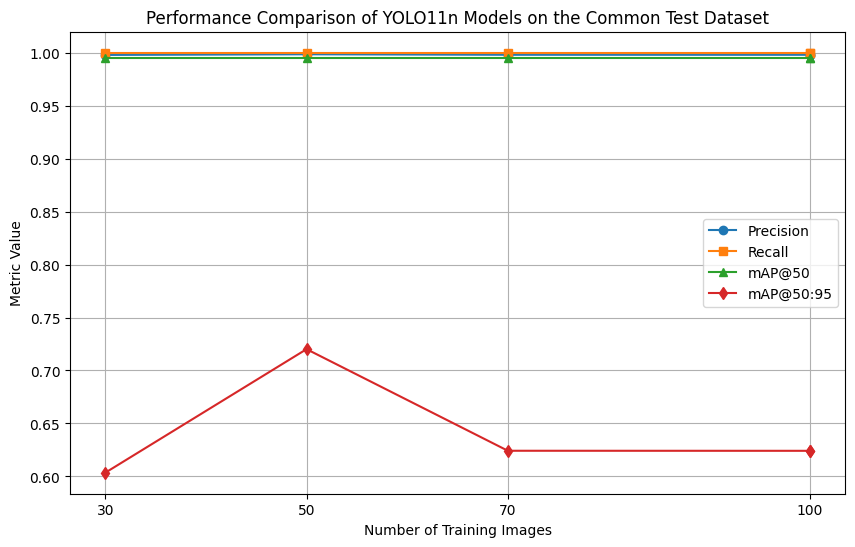

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(results_file)
df = df.sort_values("Training Images")

plt.figure(figsize=(10,6))

plt.plot(df["Training Images"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Training Images"], df["Recall"], marker='s', label="Recall")
plt.plot(df["Training Images"], df["mAP50"], marker='^', label="mAP@50")
plt.plot(df["Training Images"], df["mAP50:95"], marker='d', label="mAP@50:95")

plt.xlabel("Number of Training Images")
plt.ylabel("Metric Value")
plt.title("Performance Comparison of YOLO11n Models on the Common Test Dataset")

plt.xticks([30, 50, 70, 100])
plt.grid(True)
plt.legend()

graph_path = os.path.join(GRAPHS_DIR, "Common_Test_Performance.png")
plt.savefig(graph_path, dpi=300, bbox_inches="tight")

plt.show()